In [1]:
# Import libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# PyTorch dataset
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

# PyTorch model
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('Training on CPU ...')
else:
    print('Training on GPU ...')

Training on CPU ...


In [3]:
# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 64
# percentage of training set to use as validation
valid_size = 0.2

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

def load_data(csv_file):
    # Load CSV data
    data = pd.read_csv(csv_file)
    return data

def preprocess_features(data, feature_columns):
    # Select numeric features for scaling
    numeric_features = data[feature_columns].select_dtypes(include=[np.number])  # Assumes only numeric cols
    # Normalize numeric features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(numeric_features)
    data.loc[:, numeric_features.columns] = scaled_features  # Replace original with scaled
    return data[feature_columns]

def preprocess_labels(data, label_column):
    # Convert labels to categorical (one-hot encoding) if necessary
    labels = pd.get_dummies(data[label_column]).values
    return labels

def split_data(features, labels, test_size=0.2, val_size=0.1):
    # Split data into training and testing
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=test_size, random_state=42)
    # Split training data to training and validation
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_size, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

In [59]:
csv_file = '/content/drive/MyDrive/Progect/training_features.csv'
feature_columns = ['chroma_stft','rmse', 'spectral_centroid','spectral_bandwidth','rolloff','zero_crossing_rate','mfcc1','mfcc2','mfcc3','mfcc4','mfcc5','mfcc6','mfcc7','mfcc8','mfcc9','mfcc10','mfcc11','mfcc12','mfcc13','mfcc14','mfcc15','mfcc16','mfcc17','mfcc18','mfcc19','mfcc20']  # Replace with your feature column names
label_column = 'label'  # Replace with your label column name

# Load and preprocess data
data = load_data(csv_file)
# print(data.filename)
features = preprocess_features(data, feature_columns)
labels = preprocess_labels(data, label_column)

# Split data into training, validation, and test datasets
X_train, X_val, X_test, y_train, y_val, y_test = split_data(features, labels)

X_train = X_train.to_numpy()
# y_train = y_train.to_numpy()
X_test = X_test.to_numpy()
# y_test = y_test.to_numpy()
X_val = X_val.to_numpy()
# y_val = y_val.to_numpy()

In [147]:
# Treat each feature as a channel in a 1xN image
tensor_x_train = torch.Tensor(X_train).view(-1, X_train.shape[1], 1, 1)  # Reshape to [batch_size, features, 1, 1]
tensor_x_val = torch.Tensor(X_val).view(-1, X_val.shape[1], 1, 1)

# Reshape into a square image (assuming sqrt(features) is an integer)
dim = int(X_train.shape[1])
tensor_x_train = torch.Tensor(X_train).view(-1, 1, dim)  # Reshape to [batch_size, 1, dim, dim]
tensor_x_val = torch.Tensor(X_val).view(-1, 1, dim)

In [111]:
import torch
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset

import os


In [112]:
def prepare_dataloaders(X_train, y_train, X_val, y_val, batch_size=64):
    # Convert data to tensors
    tensor_x_train = torch.Tensor(X_train)  # transform to torch tensor
    tensor_y_train = torch.Tensor(y_train).long()

    tensor_x_val = torch.Tensor(X_val)
    tensor_y_val = torch.Tensor(y_val).long()

    # Create dataset
    train_dataset = TensorDataset(tensor_x_train, tensor_y_train)
    val_dataset = TensorDataset(tensor_x_val, tensor_y_val)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

In [126]:
train_loader,valid_loader = prepare_dataloaders(tensor_x_train, y_train, tensor_x_val, y_val, batch_size=64)
len(train_loader)

58

In [127]:
# obtain training indices that will be used for validation
num_train = len(train_loader)
indices = list(range(num_train))
np.random.shuffle(indices)
#split = int(np.floor(valid_size * num_train))
#train_idx, valid_idx = indices[split:], indices[:split]

In [128]:
# specify the image classes
classes = ['prog','nonProg']
classes

['prog', 'nonProg']

In [134]:
# define the CNN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # Change 1 to 3 to match RGB input
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Max pooling layer
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 16 * 16, 300)  # Adjust the flattening to match the output size
        self.fc2 = nn.Linear(300, 150)
        self.fc3 = nn.Linear(150, 75)
        self.fc4 = nn.Linear(75, 30)
        self.fc5 = nn.Linear(30, 2)

        # Dropout layer
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # Convolutional layers with relu and pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))  # Apply the fourth conv layer

        # Flatten the output for the fully connected layer
        x = x.view(-1, 128 * 16 * 16)  # Adjust the flattening based on the conv4 output

        # Fully connected layers with dropout
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = F.relu(self.fc3(x))  # You forgot to apply relu here
        x = self.dropout(F.relu(self.fc4(x)))  # Apply dropout correctly and relu
        x = self.fc5(x)  # No activation here since it's your output layer, assuming it's for a binary classification

        return x


In [135]:
# create a complete CNN
model = Net()
model

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=150, bias=True)
  (fc3): Linear(in_features=150, out_features=75, bias=True)
  (fc4): Linear(in_features=75, out_features=30, bias=True)
  (fc5): Linear(in_features=30, out_features=2, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

In [136]:
# move tensors to GPU if CUDA is available
if train_on_gpu:
    model.cuda()

In [137]:
# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss()

# specify optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [138]:
# number of epochs to train the model
n_epochs = 30

valid_loss_min = np.Inf # track change in validation loss

for epoch in range(1, n_epochs+1):

    # keep track of training and validation loss
    train_loss = 0.0
    valid_loss = 0.0

    ###################
    # train the model #
    ###################
    model.train()
    for data, target in train_loader:
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update training loss
        train_loss += loss.item()*data.size(0)

    ######################
    # validate the model #
    ######################
    model.eval()
    for data, target in valid_loader:
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # update average validation loss
        valid_loss += loss.item()*data.size(0)

    # calculate average losses
    train_loss = train_loss/len(train_loader.sampler)
    valid_loss = valid_loss/len(valid_loader.sampler)

    # print training/validation statistics
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch, train_loss, valid_loss))

    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model_progect.pt')
        # valid_loss_min = valid_loss

RuntimeError: Given groups=1, weight of size [16, 3, 3, 3], expected input[1, 64, 1, 26] to have 3 channels, but got 64 channels instead

###  Load the Model with the Lowest Validation Loss

In [ ]:
model.load_state_dict(torch.load('model_progect.pt'))

<All keys matched successfully>

In [ ]:
# track test loss
test_loss = 0.0
class_correct = list(0. for i in range(2))
class_total = list(0. for i in range(2))
print(len(test_loader))
model.eval()
# iterate over test data
for data, target in test_loader:
    print(len(target.data))
    # move tensors to GPU if CUDA is available
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(data)
    # calculate the batch loss
    loss = criterion(output, target)
    # update test loss
    test_loss += loss.item()*data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)
    # compare predictions to true label
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.numpy()) if not train_on_gpu else np.squeeze(correct_tensor.cpu().numpy())
    # calculate test accuracy for each object class
    for i in range(min(batch_size,len(target.data))):
        print(batch_size)
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# average test loss
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(2):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

1
45
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
Test Loss: 1.153514

Test Accuracy of  prog: 100% (10/10)
Test Accuracy of nonProg:  0% ( 0/35)

Test Accuracy (Overall): 22% (10/45)


### Visualize Sample Test Results

64


NameError: name 'imshow' is not defined

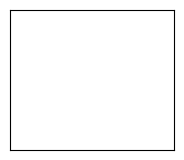

In [ ]:
# obtain one batch of test images
dataiter1 = iter(valid_loader)
images, labels = next(dataiter1)
images = images.numpy()


images = torch.from_numpy(images)
print(len(images))
# move model inputs to cuda, if GPU available
if train_on_gpu:
    images = images.cuda()

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds_tensor = torch.max(output, 1)
preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(len(images)):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    imshow(images[idx] if not train_on_gpu else images[idx].cpu())
    ax.set_title("{} ({})".format(classes[preds[idx]], classes[labels[idx]]),
                 color=("green" if preds[idx]==labels[idx].item() else "red"))